# 00 Data Sanity

Load one 3D MRI sample, inspect shape/header/intensity, and visualize orthogonal middle slices. No NeuroVFM call here.

In [1]:
from pathlib import Path
import sys

REPO = Path.cwd().resolve()
if not (REPO / 'src').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from neuro_evidence.data import load_config, config_path, nifti_summary, load_nifti_array

cfg = load_config(REPO / 'configs' / 'baseline.yaml')
sample_mri = config_path(cfg, 'sample_mri')
print('repo:', REPO)
print('sample_mri:', sample_mri)
print('exists:', sample_mri.exists())

repo: /home/dev/NeuRL
sample_mri: /home/dev/NeuRL/../brainet/data/oasis/processed_mri/shared_n4_hdbet_crop/OAS30758_V01_I11215882.nii.gz
exists: True


In [2]:
summary = nifti_summary(sample_mri)
print('shape:', summary['shape'])
print('dtype:', summary['dtype'])
print('zooms:', summary['zooms'])
print('intensity min/max/mean:', summary['min'], summary['max'], summary['mean'])
print('affine:\n', summary['affine'])

shape: (118, 163, 126)
dtype: float32
zooms: (1.0, 1.0, 1.0)
intensity min/max/mean: -0.02753795124590397 387.1573791503906 79.704833984375
affine:
 [[ 9.97503221e-01 -6.39090389e-02 -3.00490800e-02 -4.83260727e+01]
 [ 5.67846261e-02  9.78809476e-01 -1.96742192e-01 -5.65310593e+01]
 [ 4.19859290e-02  1.94544643e-01  9.79994655e-01 -9.31880646e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


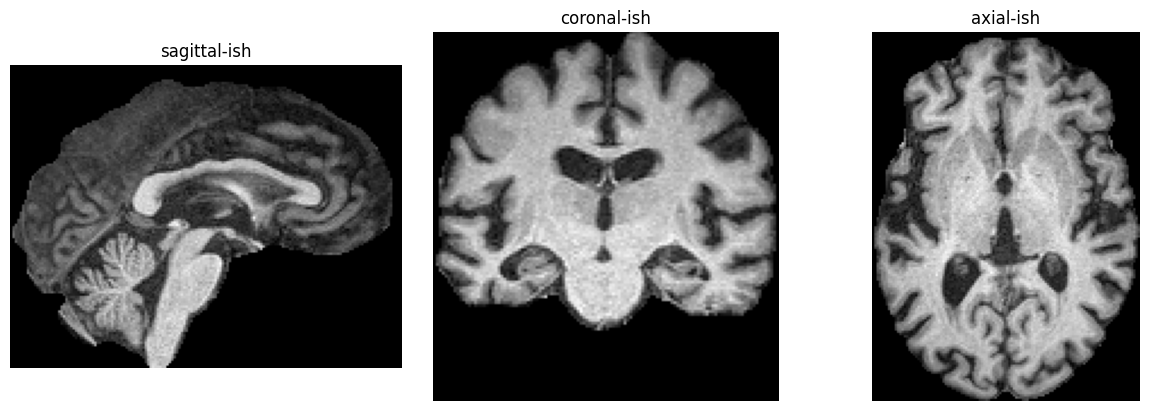

In [3]:
import matplotlib.pyplot as plt
import numpy as np

vol, affine = load_nifti_array(sample_mri)
mid = tuple(s // 2 for s in vol.shape[:3])
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
planes = [
    (vol[mid[0], :, :], 'sagittal-ish'),
    (vol[:, mid[1], :], 'coronal-ish'),
    (vol[:, :, mid[2]], 'axial-ish'),
]
for ax, (img, title) in zip(axes, planes):
    ax.imshow(np.rot90(img), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.show()